##### Copyright 2020 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

: 

# Simple audio recognition: Recognizing keywords

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/audio/simple_audio">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/audio/simple_audio.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to preprocess audio files in the WAV format and build and train a basic [automatic speech recognition](https://en.wikipedia.org/wiki/Speech_recognition) (ASR) model for recognizing ten different words. You will use a portion of the [Speech Commands dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) ([Warden, 2018](https://arxiv.org/abs/1804.03209)), which contains short (one-second or less) audio clips of commands, such as "down", "go", "left", "no", "right", "stop", "up" and "yes".

Real-world speech and audio recognition [systems](https://ai.googleblog.com/search/label/Speech%20Recognition) are complex. But, like [image classification with the MNIST dataset](../quickstart/beginner.ipynb), this tutorial should give you a basic understanding of the techniques involved.

> **Adapted for the ESP32-S3 `micro_speech` firmware project.** The stock
> tutorial below trains on a raw STFT spectrogram (`tf.signal.stft`), but the
> firmware's on-device pipeline (`micro_features_generator.cc`) does not
> produce that — it runs a dedicated frontend model that computes a
> mel-filterbank spectrogram with noise reduction and PCAN auto-gain control,
> fixed at a 30ms window / 20ms stride / 40 channels (see
> `micro_speech/main/micro_model_settings.h`).
>
> This notebook replaces the STFT step with TensorFlow's `audio_microfrontend`
> op, configured with those same settings, so the classifier trains on
> features that match what the firmware will actually feed it at inference
> time. It also switches the final quantization to full `int8` (the firmware
> requires `kTfLiteInt8`, not `uint8`).

## Setup

Import necessary modules and dependencies. You'll be using `tf.keras.utils.audio_dataset_from_directory` (introduced in TensorFlow 2.10), which helps generate audio classification datasets from directories of `.wav` files. You'll also need [seaborn](https://seaborn.pydata.org) for visualization in this tutorial.

In [1]:
!pip install -U -q tensorflow tensorflow_datasets

In [4]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

I0000 00:00:1782994923.402564   16567 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782994923.407113   16567 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782994924.024034   16567 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782994925.833984   16567 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Import the mini Speech Commands dataset

To save time with data loading, you will be working with a smaller version of the Speech Commands dataset. The [original dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) consists of over 105,000 audio files in the [WAV (Waveform) audio file format](https://www.aelius.com/njh/wavemetatools/doc/riffmci.pdf) of people saying 35 different words. This data was collected by Google and released under a CC BY license.

Download and extract the `mini_speech_commands.zip` file containing the smaller Speech Commands datasets with `tf.keras.utils.get_file`:

In [5]:
DATASET_PATH = 'data/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

182082353/182082353 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


The dataset's audio clips are stored in eight folders corresponding to each speech command: `no`, `yes`, `down`, `go`, `left`, `up`, `right`, and `stop`:

In [6]:
from pathlib import Path

# Resolve relative to the notebook's own directory, so this works regardless
# of who runs it or where the repo is checked out.
data_dir = Path.cwd() / "data" / "mini_speech_commands_extracted" / "mini_speech_commands"
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != 'README.md') & (commands != '.DS_Store')]
print('Commands:', commands)

Commands: ['stop' 'down' 'right' 'no' 'go' 'left' 'up' 'yes']


Divided into directories this way, you can easily load the data using `keras.utils.audio_dataset_from_directory`. 

The audio clips are 1 second or less at 16kHz. The `output_sequence_length=16000` pads the short ones to exactly 1 second (and would trim longer ones) so that they can be easily batched.

In [7]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print("label names:", label_names)

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.
label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


E0000 00:00:1782994975.452955   16567 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


This dataset only contains single channel audio, so use the `tf.squeeze` function to drop the extra axis:

In [9]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

The `utils.audio_dataset_from_directory` function only returns up to two splits. It's a good idea to keep a test set separate from your validation set.
Ideally you'd keep it in a separate directory, but in this case you can use `Dataset.shard` to split the validation set into two halves. Note that iterating over **any** shard will load **all** the data, and only keep its fraction. 

In [10]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

## Convert waveforms to on-device-matching features

Instead of a raw linear-frequency STFT, generate the same kind of
mel-filterbank + noise-reduction + PCAN + log-compressed features the ESP32
firmware computes on-device. TensorFlow's `audio_microfrontend` op implements
that exact algorithm (window -> FFT -> filterbank -> noise reduction -> PCAN
-> log), so it's configured here with the same constants used in
`micro_speech/main/micro_model_settings.h`.

In [ ]:
from tensorflow.lite.experimental.microfrontend.python.ops import audio_microfrontend_op as frontend_op

# Mirrors micro_speech/main/micro_model_settings.h
AUDIO_SAMPLE_RATE = 16000
FEATURE_DURATION_MS = 30   # kFeatureDurationMs
FEATURE_STRIDE_MS = 20     # kFeatureStrideMs
FEATURE_SIZE = 40          # kFeatureSize (mel channels)
FEATURE_COUNT = 49         # kFeatureCount (time slices per 1s clip)
BATCH_SIZE = 64            # matches audio_dataset_from_directory above


def get_frontend_features(waveform):
  """Compatible with micro_speech:  window -> FFT -> mel filterbank -> noise reduction ->
  PCAN auto-gain -> log compression, at the same 30ms window / 20ms stride /
  40-channel settings the firmware uses. Returns a (FEATURE_COUNT,
  FEATURE_SIZE, 1) float32 tensor.

  Note: this runs in float32 via TensorFlow's audio_microfrontend op, while
  the firmware runs an int8-quantized graph of equivalent ops on-device, so
  results are the same algorithm but not bit-exact.
  """
  # audio_dataset_from_directory normalizes int16 PCM to float32 [-1, 1];
  # the frontend expects raw int16 samples like the mic ADC/I2S data
  pcm16 = tf.cast(tf.clip_by_value(waveform * 32768.0, -32768, 32767), tf.int16)
  features = frontend_op.audio_microfrontend(
      pcm16,
      sample_rate=AUDIO_SAMPLE_RATE,
      window_size=FEATURE_DURATION_MS,
      window_step=FEATURE_STRIDE_MS,
      num_channels=FEATURE_SIZE,
      enable_pcan=True,
      out_scale=1,
      out_type=tf.float32,
  )
  return features[..., tf.newaxis]


def make_feature_ds(ds):
  return (
      ds.unbatch()
        .map(lambda audio, label: (get_frontend_features(audio), label),
             num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
  )


train_feature_ds = make_feature_ds(train_ds)
val_feature_ds = make_feature_ds(val_ds)
test_feature_ds = make_feature_ds(test_ds)


## Build and train the model

Add `Dataset.cache` and `Dataset.prefetch` operations to reduce read latency while training the model:

In [12]:
train_feature_ds = train_feature_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_feature_ds = val_feature_ds.cache().prefetch(tf.data.AUTOTUNE)
test_feature_ds = test_feature_ds.cache().prefetch(tf.data.AUTOTUNE)


For the model, you'll use a simple convolutional neural network (CNN).

Unlike the original tutorial, there's no `Resizing` layer here: the STFT
spectrogram was resized down from a large 124x129 image, but the frontend's
49x40 feature grid is already small enough to feed directly.

The `Normalization` layer still needs its `adapt` method called on the
training data first, to compute the mean/std it will use to rescale inputs.

In [16]:
input_shape = (FEATURE_COUNT, FEATURE_SIZE, 1)
print('Input shape:', input_shape)
num_labels = len(label_names)

norm_layer = layers.Normalization()
norm_layer.adapt(data=train_feature_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    norm_layer,
    layers.Conv2D(16, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (49, 40, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 49, 40, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 38, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 47, 38, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 19, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 17, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 17, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,939 (863.05 KB)

 Trainable params: 220,712 (862.16 KB)

 Non-trainable params: 227 (912.00 B)

Configure the Keras model with the Adam optimizer and the cross-entropy loss:

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

Train the model over 10 epochs for demonstration purposes:

In [18]:
EPOCHS = 100
history = model.fit(
    train_feature_ds,
    validation_data=val_feature_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(
        verbose=1, patience=10, restore_best_weights=True),
)

Epoch 1/100


     99/Unknown 7s 50ms/step - accuracy: 0.2930 - loss: 2.1456

/home/ahmed/ESP32_AI_voice_detector_with_docs/.venv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.4059 - loss: 1.6749 - val_accuracy: 0.2708 - val_loss: 1.8152
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6742 - loss: 0.8686 - val_accuracy: 0.5013 - val_loss: 1.3873
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7730 - loss: 0.6014 - val_accuracy: 0.7305 - val_loss: 0.7474
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8295 - loss: 0.4613 - val_accuracy: 0.7773 - val_loss: 0.5872
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8598 - loss: 0.3769 - val_accuracy: 0.8190 - val_loss: 0.5534
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8817 - loss: 0.3206 - val_accuracy: 0.8359 - val_loss: 0.4743
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9058 - loss: 0.2610 - val_accuracy: 0.8242 - val_loss: 0.5166
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9175 - loss: 0.2242 - val_accuracy

Let's plot the training and validation loss curves to check how your model has improved during training:

Text(0, 0.5, 'Accuracy [%]')

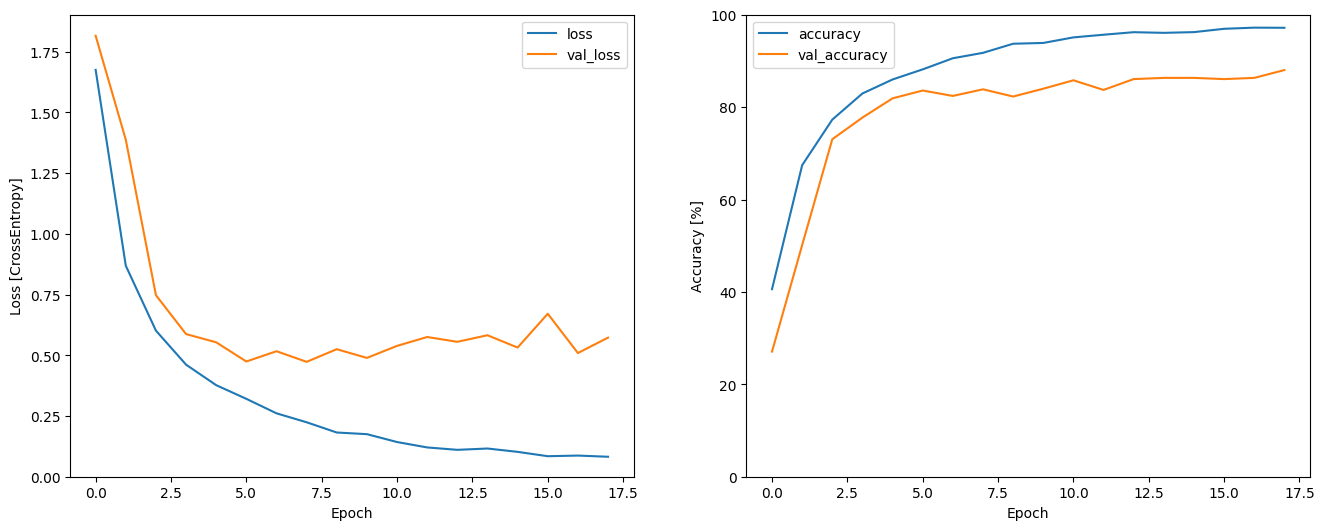

In [19]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Evaluate the model performance

Run the model on the test set and check the model's performance:

In [21]:
model.evaluate(test_feature_ds, return_dict=True)


      8/Unknown 0s 16ms/step - accuracy: 0.8036 - loss: 0.6117

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8438 - loss: 0.4712


{'accuracy': 0.84375, 'loss': 0.4712342619895935}

### Display a confusion matrix

Use a [confusion matrix](https://developers.google.com/machine-learning/glossary#confusion-matrix) to check how well the model did classifying each of the commands in the test set:


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


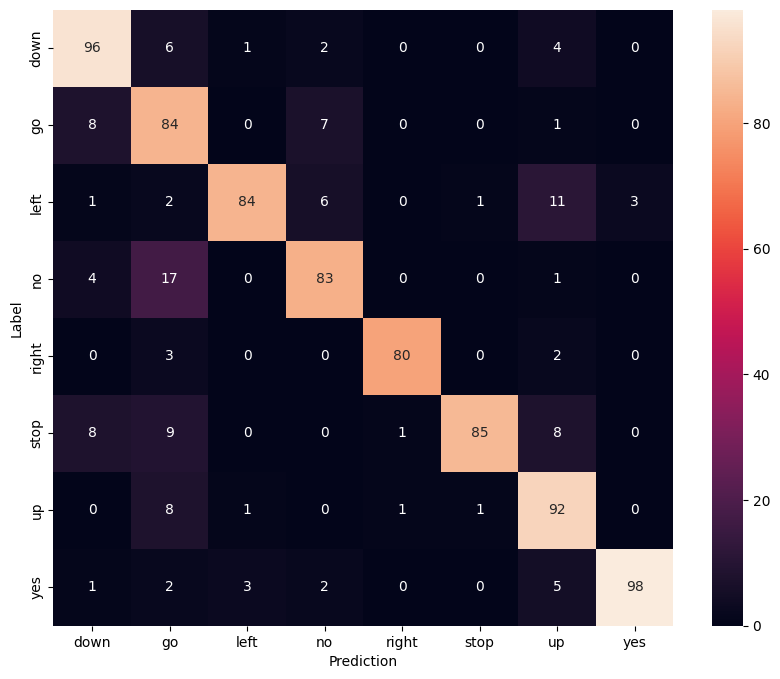

In [22]:
y_pred = model.predict(test_feature_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(test_feature_ds.map(lambda s, lab: lab)), axis=0)

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()


## Save the trained model

In [23]:
model.save("keyword_spotting_cnn.keras")


### Convert using integer-only quantization

In [24]:
def representative_data_gen(num_samples=300):
    """Yields calibration samples using the same on-device-matching
    frontend features the classifier trains on."""
    audio_paths = []
    for cmd in label_names:
        audio_paths.extend((data_dir / cmd).glob('*.wav'))

    # Shuffle for a diverse sample, but keep it deterministic/reproducible.
    rng = np.random.RandomState(42)
    rng.shuffle(audio_paths)

    for audio_path in audio_paths[:num_samples]:
        audio_binary = tf.io.read_file(str(audio_path))
        waveform, _ = tf.audio.decode_wav(audio_binary, desired_channels=1,
                                           desired_samples=AUDIO_SAMPLE_RATE)
        waveform = tf.squeeze(waveform, axis=-1)
        features = get_frontend_features(waveform)
        yield [features[tf.newaxis, ...]]


Load the saved Keras model and quantize it to int8:

In [ ]:
model_path = Path.cwd() / "keyword_spotting_cnn.keras"
loaded_model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
# Ensure that if any ops can't be quantized, the converter throws an error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# main_functions.cc requires the model's input/output tensors to be int8
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp9s3mei5d/assets


INFO:tensorflow:Assets written to: /tmp/tmp9s3mei5d/assets


Saved artifact at '/tmp/tmp9s3mei5d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  126472700020864: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  126472700034240: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  126472699961488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700023152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700366688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700363520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700363696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700365984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700377248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126472700374784: TensorSpec(shape=(), dtype=tf.resource, name=None)

/home/ahmed/ESP32_AI_voice_detector_with_docs/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782997297.354615   16567 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782997297.354798   16567 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782997297.356303   16567 reader.cc:83] Reading SavedModel from: /tmp/tmp9s3mei5d
I0000 00:00:1782997297.356991   16567 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782997297.357001   16567 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9s3mei5d
I0000 00:00:1782997297.374020   16567 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782997297.375926   16567 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782997297.447002   16567 loader.cc:220] Running in

**Examine data type after conversion**

In [26]:
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']
print('input: ', input_type)
output_type = interpreter.get_output_details()[0]['dtype']
print('output: ', output_type)
assert input_type == np.int8, "Firmware requires an int8 input tensor"
assert output_type == np.int8, "Firmware requires an int8 output tensor"


input:  <class 'numpy.int8'>
output:  <class 'numpy.int8'>


/home/ahmed/ESP32_AI_voice_detector_with_docs/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Generate the .tflite int8 quantized model:

In [27]:
tflite_models_dir = Path.cwd()

tflite_model_quant_file = tflite_models_dir / "keyword_spotting_int8.tflite"
tflite_model_quant_file.write_bytes(tflite_model_quant)

233544

## Evaluate the quantized model

In [28]:
tflite_model_quant_file = Path.cwd() / "keyword_spotting_int8.tflite"
interpreter = tf.lite.Interpreter(model_path=str(tflite_model_quant_file))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Helper to run the quantized model on a single `.wav` file:

In [29]:
def run_tflite_model(audio_path):
    """Runs inference on a single .wav file using the quantized model."""
    audio_binary = tf.io.read_file(str(audio_path))
    waveform, _ = tf.audio.decode_wav(audio_binary, desired_channels=1,
                                       desired_samples=AUDIO_SAMPLE_RATE)
    waveform = tf.squeeze(waveform, axis=-1)

    features = get_frontend_features(waveform)
    features = features[tf.newaxis, ...].numpy()

    # Handle int8 quantization scaling.
    input_scale, input_zero_point = input_details["quantization"]
    features = features / input_scale + input_zero_point
    features = features.astype(input_details["dtype"])

    interpreter.set_tensor(input_details["index"], features)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details["index"])[0]

    return output.argmax()  # Return predicted label index


Evaluate accuracy of the quantized model on held-out files:

In [ ]:
def evaluate_quantized_model(dataset):
    """Evaluates the quantized model's accuracy on a held-out dataset"""
    correct_predictions = 0
    total_predictions = 0

    for waveform, label in dataset.unbatch():
        true_label = label_names[label.numpy()]

        features = get_frontend_features(waveform)
        features = features[tf.newaxis, ...].numpy()
        input_scale, input_zero_point = input_details["quantization"]
        features = features / input_scale + input_zero_point
        features = features.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], features)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]
        predicted_label = label_names[output.argmax()]

        if predicted_label == true_label:
            correct_predictions += 1
        total_predictions += 1

    accuracy = (correct_predictions / total_predictions) * 100
    print(f"Quantized model accuracy: {accuracy:.2f}% ({correct_predictions}/{total_predictions})")


evaluate_quantized_model(test_ds)


Quantized model accuracy: 84.50% (703/832)
